# import thư viện

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# thêm dữ liệu


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Path to dataset files:", path)

c:\Users\lazyg\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.03G/1.03G [00:40<00:00, 27.4MB/s]

Extracting files...


Path to dataset files: C:\Users\lazyg\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1


In [3]:
import os
DATA_DIR=os.path.join(path, "asl_alphabet_train/asl_alphabet_train")

#  chuẩn hóa dữ liệu


In [4]:
#Khai bao tham so
IMG_SIZE = 64
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 29

In [5]:
#Tang cuong du lieu
train_datagen = ImageDataGenerator(
    rescale= 1./255,#chuyen mau
    validation_split= 0.2,#20%test,80%train
    rotation_range=20,#Xoay anh
    zoom_range=0.2,#phong to anh
    width_shift_range=0.2,#dich chuyen anh theo chieu ngang
    height_shift_range=0.2,#dich chuyen anh theo chieu doc
    horizontal_flip=False,#khong lat ngang anh
)

test_datagen=ImageDataGenerator(rescale=1./255, validation_split=0.2)

In [7]:
#load train data
train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 69600 images belonging to 29 classes.


In [ ]:
#load validation data
validation_generator=train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 17400 images belonging to 29 classes.


## Chú thích về validation:
- Tập `train` có mục đích là học
- Tập `validation` theo dõi khi train: *đem model đang học đi test với tập val -> không cập nhật weight mà chi đo `val_loss`, `val_accuracy`*
- Tập `test` đánh giá cuối cùng (người dùng tự test)

Số lớp: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


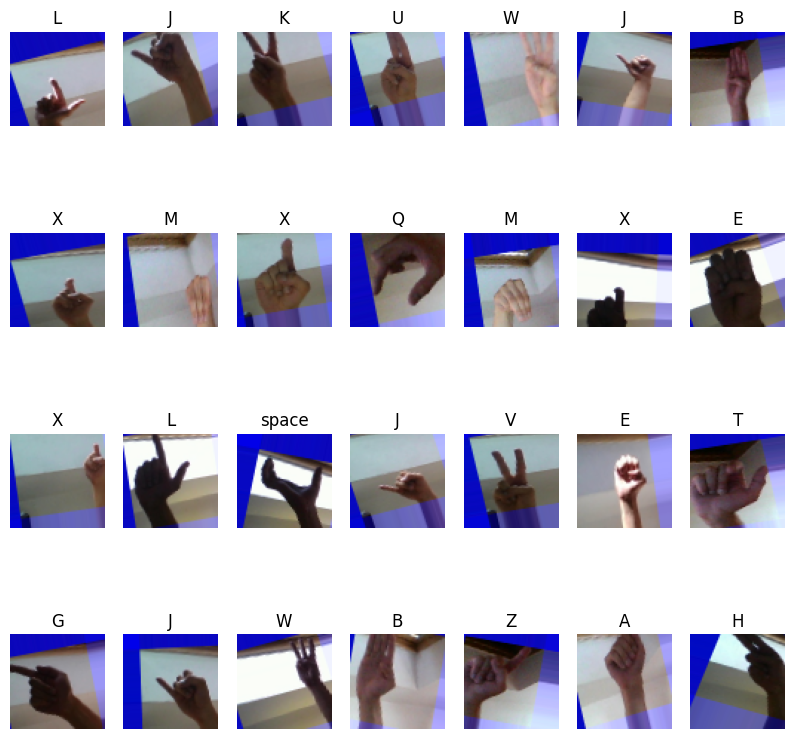

In [13]:
class_names = list(train_generator.class_indices.keys())
print("Số lớp:", len(class_names))
print(class_names)

import matplotlib.pyplot as plt
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(28):
    plt.subplot(4,7,i+1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

plt.show()

# khai báo mô hình 

In [23]:
#CNN
model= Sequential([
    Conv2D(32, (3,3), 
        activation='relu',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), 
        activation='relu'),
        MaxPooling2D(2,2),
       

        Conv2D(128, (3,3), 
        activation='relu'),
        MaxPooling2D(2,2),
    

    Flatten(),
    Dense(256, activation='relu'),

    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

c:\Users\lazyg\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
                metrics=['accuracy']
            )
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,605 (4.89 MB)

 Trainable params: 1,280,605 (4.89 MB)

 Non-trainable params: 0 (0.00 B)

# train mô hình

In [26]:
history = model.fit(train_generator, validation_data=validation_generator, epochs=EPOCHS)  

Epoch 1/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 247s 113ms/step - accuracy: 0.4460 - loss: 1.7989 - val_accuracy: 0.7283 - val_loss: 0.8667
Epoch 2/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 251s 115ms/step - accuracy: 0.7564 - loss: 0.7265 - val_accuracy: 0.8312 - val_loss: 0.5311
Epoch 3/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 237s 109ms/step - accuracy: 0.8414 - loss: 0.4753 - val_accuracy: 0.8625 - val_loss: 0.4289
Epoch 4/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 235s 108ms/step - accuracy: 0.8779 - loss: 0.3632 - val_accuracy: 0.8642 - val_loss: 0.4596
Epoch 5/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 248s 114ms/step - accuracy: 0.9017 - loss: 0.2961 - val_accuracy: 0.8528 - val_loss: 0.5057
Epoch 6/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 234s 107ms/step - accuracy: 0.9140 - loss: 0.2606 - val_accuracy: 0.8833 - val_loss: 0.3872
Epoch 7/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 224s 103ms/step - accuracy: 0.9253 - loss: 0.2288 - val_accuracy: 0.8703 - val_loss: 0.5315
Epoch 8/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 222s 102ms/step - ac

In [27]:
# luu mo hinh
model.save("asl_model.h5")
print("Da luu model thanh cong!")

Da luu model thanh cong!


# danh gia mo hinh


In [28]:
#kieu phan lop->Loss accuracy
loss, accuracy= model.evaluate(validation_generator)
print(f"Test loss:{loss:.4f}")
print(f"Test accuracy:{accuracy:.4f}")

544/544 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - accuracy: 0.8878 - loss: 0.4744
Test loss:0.4744
Test accuracy:0.8878


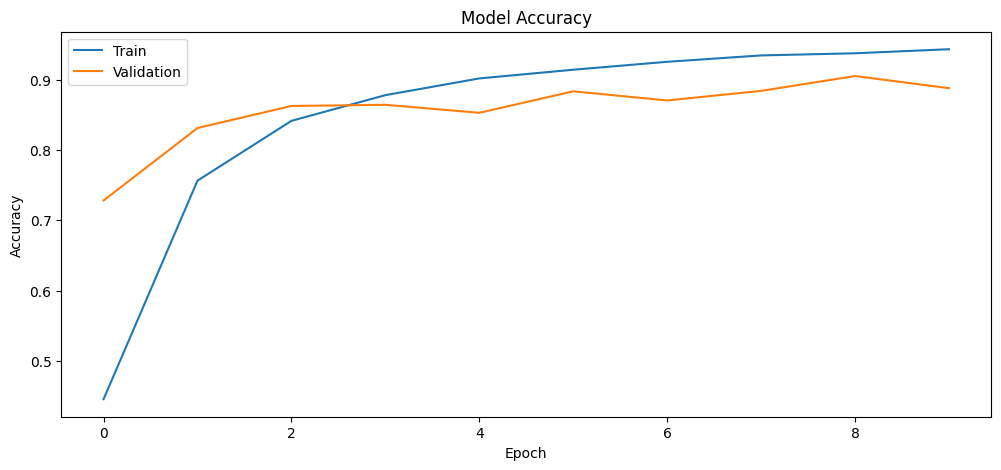

In [29]:
#bieu do accuracy
# bieu do accuracy
plt.figure(figsize=(12, 5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

# Test mô hình